In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Set plot style for better-looking presentation slides
plt.style.use('dark_background') # Looks great for crypto/cybersecurity themes
sns.set_theme(style="darkgrid")

# Load the data
df = pd.read_csv('raw_whale_transactions.csv')

# Convert timestamp to proper datetime objects for time-series analysis
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Calculate the actual USD value of the transaction at that moment
df['value_usd'] = df['value_eth'] * df['eth_price_usd']

print(f"Total transactions loaded: {len(df)}")
df.head()

Total transactions loaded: 46


,block_number,timestamp,tx_hash,from_address,to_address,value_eth,gas_price_gwei,eth_price_usd,value_usd
0,24734388,2026-03-25 13:51:47,afd50ec48a1d40fe8a13fd2a491d80d90c432209ae1c77...,0xEAF206Ba47519ECdd89Cddaa27D145B46a1B3B06,0x66a9893cC07D91D95644AEDD05D03f95e1dBA8Af,50.000000,2.070926,NaN,NaN
1,24734388,2026-03-25 13:51:47,c8a3504e50d136305470d17d1c509a3f7954c6ee17cd1d...,0xe108186A084886b0D7B054475fB834083cB6D798,0xcA4217a885f06F72f4b53132b754ad3f6BBCd5Bd,30.234743,3.064005,NaN,NaN
2,24734388,2026-03-25 13:51:47,7685ce37baf76816690ea9b14aa089691af0e6b5b65ed8...,0xa1abfA21f80ecf401bd41365adBb6fEF6fEfDF09,0xf584F8728B874a6a5c7A8d4d387C9aae9172D621,17.519400,2.070926,NaN,NaN
3,24734385,2026-03-25 13:51:11,319cf412a0edd3896f901da62ac92ecf34b29a292c9db2...,0xC2e133B37e5b4365C2Fb0B167C42Cc662D0fBf57,0xbA3cB449bD2B4ADddBc894D8697F5170800EAdeC,19.990000,2.061760,NaN,NaN
4,24734384,2026-03-25 13:50:59,426a4e8aa2a11b7cd43241eb55745af100fe805d0e0e71...,0xDFd5293D8e347dFe59E90eFd55b2956a1343963d,0xC8D63A46C089bbEB9F5b0Ff0c087972B41138DDd,116.344201,1.066575,2184.83,254192.300605


In [4]:
# Show descriptive statistics for the numerical columns
display(df[['value_eth', 'value_usd', 'gas_price_gwei']].describe())

# Find the absolute biggest transaction in your dataset
biggest_tx = df.loc[df['value_eth'].idxmax()]
print("\nLargest Transaction Found:")
print(f"Hash: {biggest_tx['tx_hash']}")
print(f"Value: {biggest_tx['value_eth']} ETH (${biggest_tx['value_usd']:,.2f})")

,value_eth,value_usd,gas_price_gwei
count,46.000000,4.200000e+01,46.000000
mean,61.406958,1.410021e+05,0.846148
std,105.136767,2.398565e+05,0.831366
min,10.110271,2.207274e+04,0.051231
25%,14.831815,3.150340e+04,0.099515
50%,25.384469,5.554651e+04,0.591456
75%,62.489227,1.402622e+05,1.083870
max,622.900110,1.364413e+06,3.064005



Largest Transaction Found:
Hash: 032e0de519a36ee223ff82e0ab2bee35cc2ff9710b2c6ea8c63c6466a09386c5
Value: 622.9001095415618 ETH ($1,364,412.86)


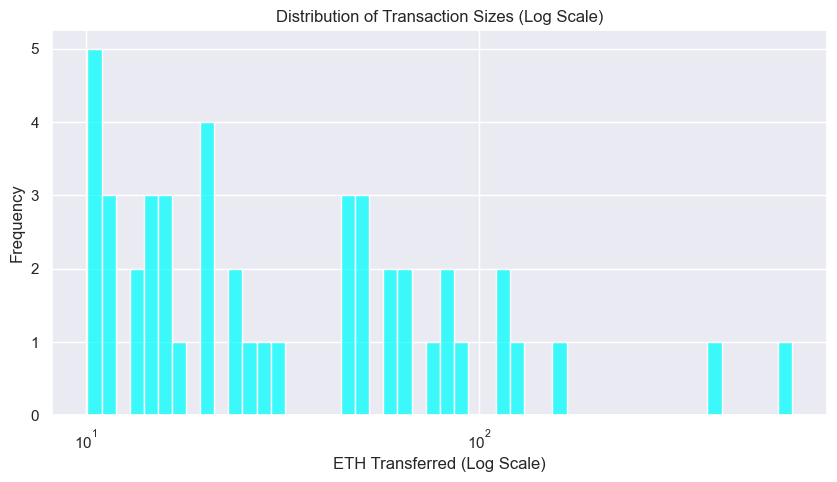

In [5]:
plt.figure(figsize=(10, 5))
# Using a log scale because crypto wealth is highly skewed
sns.histplot(df['value_eth'], bins=50, log_scale=True, color='cyan')
plt.title('Distribution of Transaction Sizes (Log Scale)')
plt.xlabel('ETH Transferred (Log Scale)')
plt.ylabel('Frequency')
plt.show()

C:\Users\jenia\AppData\Local\Temp\ipykernel_38452\411929855.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_receivers.index, x=top_receivers.values, palette='viridis')


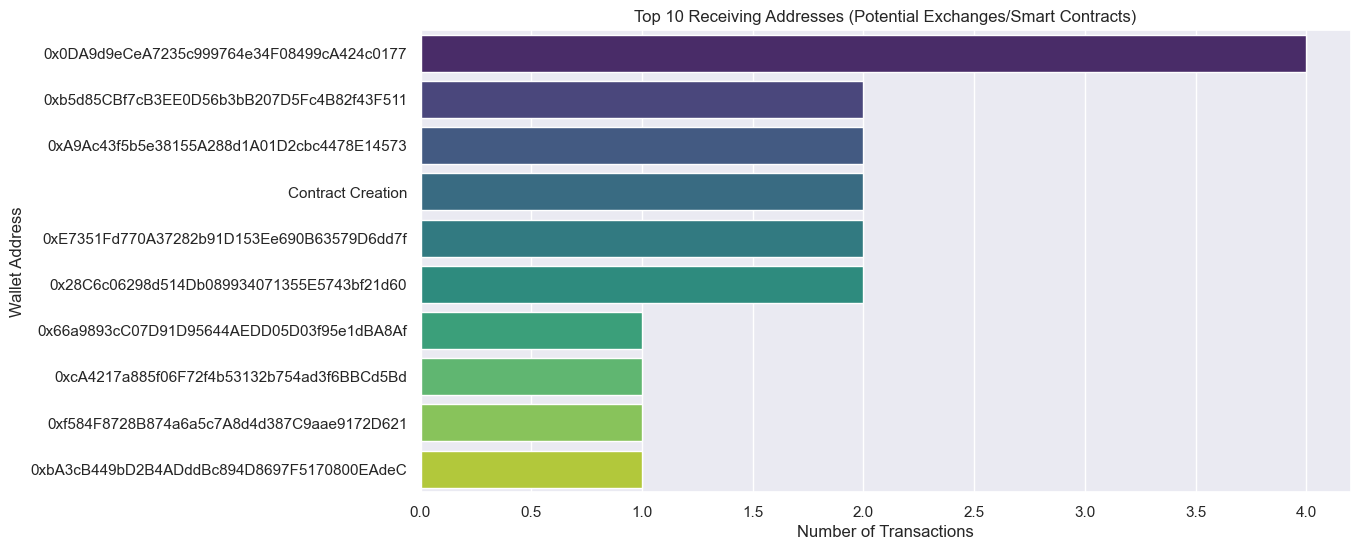

In [6]:
plt.figure(figsize=(12, 6))
top_receivers = df['to_address'].value_counts().head(10)
sns.barplot(y=top_receivers.index, x=top_receivers.values, palette='viridis')
plt.title('Top 10 Receiving Addresses (Potential Exchanges/Smart Contracts)')
plt.xlabel('Number of Transactions')
plt.ylabel('Wallet Address')
plt.show()

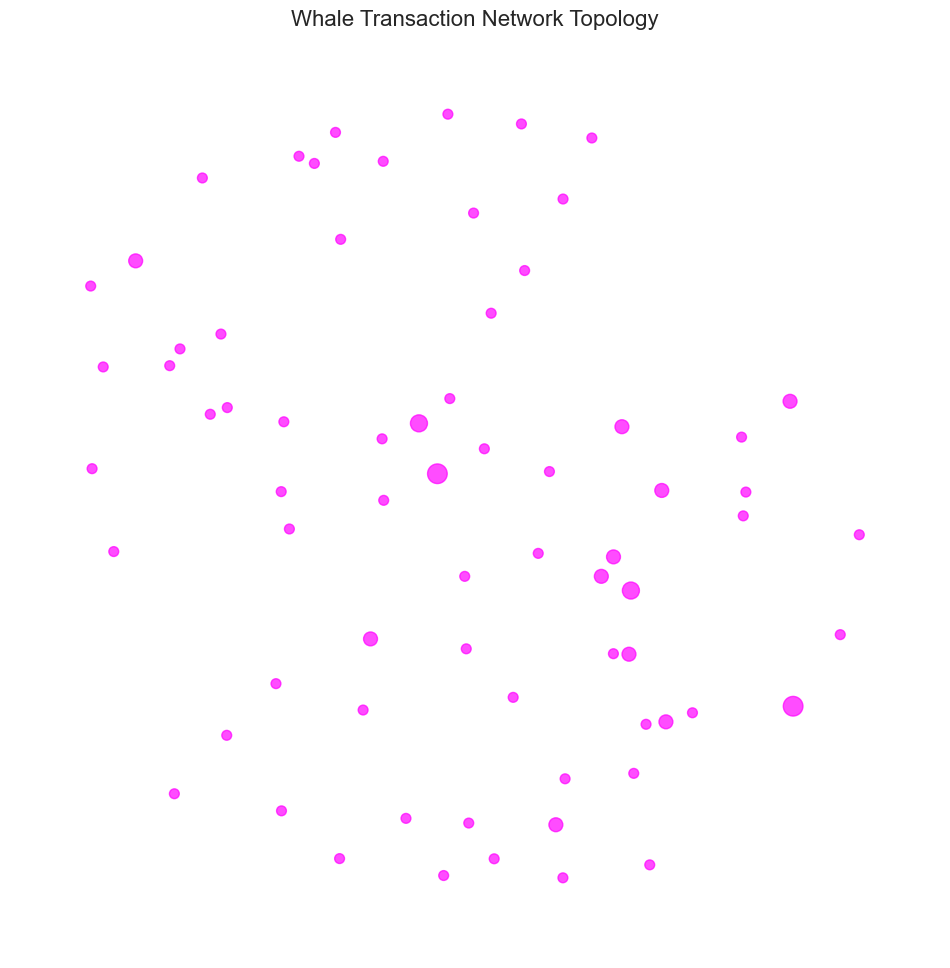

In [7]:
# Create a directed graph
G = nx.from_pandas_edgelist(
    df, 
    source='from_address', 
    target='to_address', 
    edge_attr=['value_eth'], 
    create_using=nx.DiGraph()
)

plt.figure(figsize=(12, 12))

# Calculate node sizes based on how many connections they have (degree)
degrees = dict(G.degree)
node_sizes = [v * 50 for v in degrees.values()]

# Draw the network
pos = nx.spring_layout(G, k=0.15, iterations=20)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='magenta', alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='white', arrows=True)

plt.title('Whale Transaction Network Topology', fontsize=16)
plt.axis('off')
plt.show()